# Stage 0 — Radial structure of Ganymede

Goal: a self-consistent 1D profile of density, gravity and pressure that matches Ganymede's **mass** and **moment of inertia**.
This becomes the background state for everything later (phase boundaries, the ice shell, convection).

Physics, for a spherically symmetric body in hydrostatic equilibrium:

$$m(r) = \int_0^r 4\pi r'^2 \rho\, dr', \qquad g(r) = \frac{G\,m(r)}{r^2}, \qquad \frac{dP}{dr} = -\rho g, \quad P(R)=0$$

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ganymede.constants import G, R_GANYMEDE, M_GANYMEDE, MOI_GANYMEDE
from ganymede.structure import hydrostatic_profile, layered_density, fit_three_layer

## 2. Benchmark — uniform sphere

Before trusting the integrator on Ganymede, check it against the exact solution for a uniform sphere:
$g = \tfrac{4}{3}\pi G\rho r$, $\;P = \tfrac{2}{3}\pi G \rho^2 (R^2 - r^2)$, $\;C/MR^2 = 0.4$.

In [2]:
R, rho0 = R_GANYMEDE, 1940.0          # Ganymede radius, ~its mean density
r = np.linspace(0, R, 2001)
prof = hydrostatic_profile(r, np.full_like(r, rho0))

g_exact = 4/3 * np.pi * G * rho0 * r
P_exact = 2/3 * np.pi * G * rho0**2 * (R**2 - r**2)

print(f"max |g error| = {np.max(np.abs(prof.g - g_exact)):.2e} m/s^2")
print(f"max |P error| = {np.max(np.abs(prof.P - P_exact))/1e6:.3f} MPa  (central P = {P_exact[0]/1e9:.2f} GPa)")
print(f"C/MR^2 = {prof.moi:.5f}  (exact 0.4)")

max |g error| = 2.00e-15 m/s^2
max |P error| = 0.000 MPa  (central P = 3.64 GPa)
C/MR^2 = 0.40000  (exact 0.4)


## 3. Three-layer Ganymede: iron core, silicate mantle, H$_2$O layer

Fix the three densities, solve for the two radii that reproduce $M$ and $C/MR^2 = 0.3115$.
Two unknowns, two constraints — so the answer is only as good as the density guesses (see §4).

core radius          733 km
H2O thickness        752 km
P at H2O base       1.29 GPa
centre pressure     8.40 GPa
check: M = 1.4819e+23 kg, C/MR^2 = 0.3115


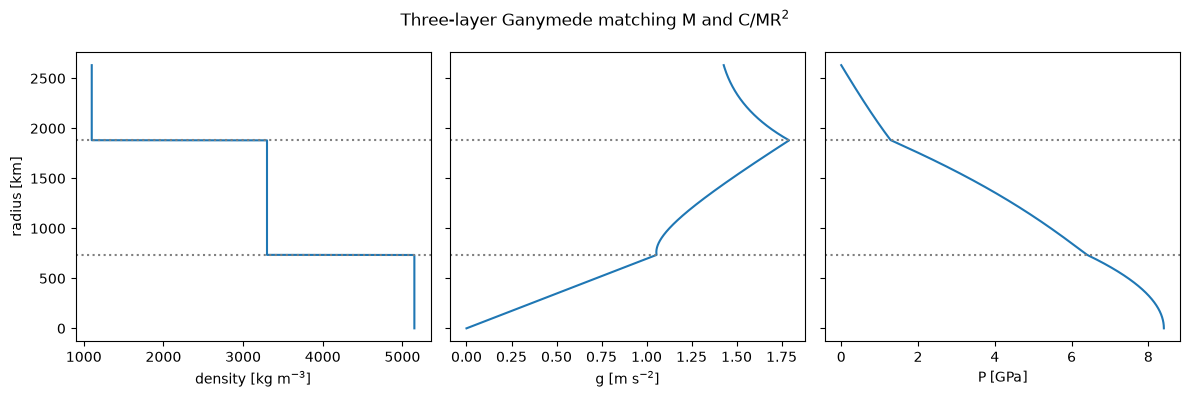

In [3]:
rho_core, rho_mantle, rho_h2o = 5150.0, 3300.0, 1100.0   # Fe-FeS, silicate, mean H2O (ice + ocean + HP ice)

r_core, r_mantle = fit_three_layer(R_GANYMEDE, M_GANYMEDE, MOI_GANYMEDE, rho_core, rho_mantle, rho_h2o)

r = np.linspace(0, R_GANYMEDE, 20001)
rho = layered_density(r, [r_core, r_mantle, R_GANYMEDE], [rho_core, rho_mantle, rho_h2o])
gan = hydrostatic_profile(r, rho)

i_h2o = np.searchsorted(r, r_mantle)
print(f"core radius      {r_core/1e3:7.0f} km")
print(f"H2O thickness    {(R_GANYMEDE - r_mantle)/1e3:7.0f} km")
print(f"P at H2O base    {gan.P[i_h2o]/1e9:7.2f} GPa")
print(f"centre pressure  {gan.P[0]/1e9:7.2f} GPa")
print(f"check: M = {gan.mass:.4e} kg, C/MR^2 = {gan.moi:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
depth_km = r / 1e3
for a, y, lab in zip(ax, [rho, gan.g, gan.P / 1e9], ["density [kg m$^{-3}$]", "g [m s$^{-2}$]", "P [GPa]"]):
    a.plot(y, depth_km)
    a.set_xlabel(lab)
    a.axhline(r_core / 1e3, ls=":", c="grey"); a.axhline(r_mantle / 1e3, ls=":", c="grey")
ax[0].set_ylabel("radius [km]")
fig.suptitle("Three-layer Ganymede matching M and C/MR$^2$")
plt.tight_layout(); plt.show()

## 4. Non-uniqueness — Monte Carlo over the assumed densities

M and C/MR² give two constraints, but the model has five unknowns (three densities, two radii).
Sample plausible densities and the C/MR² uncertainty, refit each time, and see how well the H2O thickness is actually pinned down.

physical solutions: 4385/5000
H2O thickness  median   783 km   (5–95 %: 669–906 km)
core radius    median   764 km   (5–95 %: 389–1095 km)

correlation with H2O thickness:
  rho_core   -0.05
  rho_mantle +0.48
  rho_h2o    +0.90
  C/MR^2     -0.18


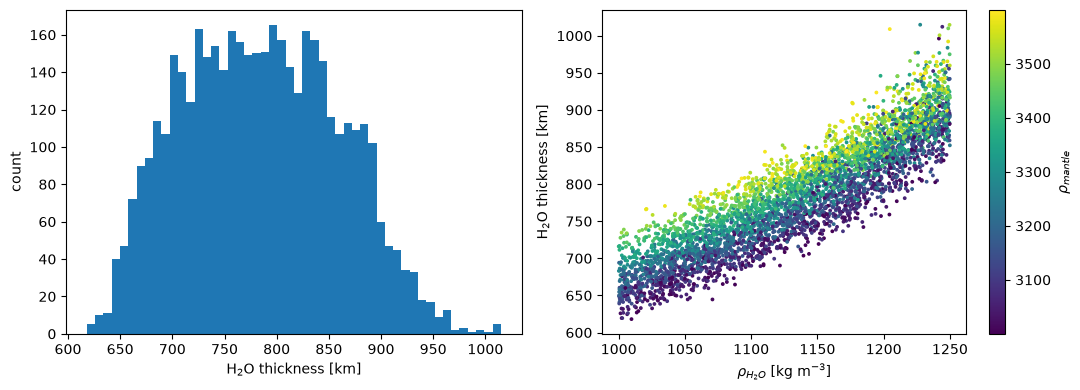

In [4]:
rng = np.random.default_rng(42)
N = 5000
samples = []
for _ in range(N):
    rc_d = rng.uniform(4500, 7000)     # Fe-FeS ... pure Fe
    rm_d = rng.uniform(3000, 3600)     # hydrated ... anhydrous silicates
    rw_d = rng.uniform(1000, 1250)     # mean H2O layer density (ice Ih + ocean + HP ice)
    moi  = rng.normal(MOI_GANYMEDE, 0.0028)
    try:
        rc, rm = fit_three_layer(R_GANYMEDE, M_GANYMEDE, moi, rc_d, rm_d, rw_d)
        samples.append((rc_d, rm_d, rw_d, moi, rc, rm))
    except ValueError:
        pass                            # no physical solution for this combination

s = np.array(samples)
h2o_km  = (R_GANYMEDE - s[:, 5]) / 1e3
core_km = s[:, 4] / 1e3
print(f"physical solutions: {len(s)}/{N}")
for name, x in [("H2O thickness", h2o_km), ("core radius", core_km)]:
    p5, p50, p95 = np.percentile(x, [5, 50, 95])
    print(f"{name:14s} median {p50:5.0f} km   (5–95 %: {p5:.0f}–{p95:.0f} km)")
print("\ncorrelation with H2O thickness:")
for i, name in enumerate(["rho_core", "rho_mantle", "rho_h2o", "C/MR^2"]):
    print(f"  {name:10s} {np.corrcoef(s[:, i], h2o_km)[0, 1]:+.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(h2o_km, bins=50); ax[0].set_xlabel("H$_2$O thickness [km]"); ax[0].set_ylabel("count")
sc = ax[1].scatter(s[:, 2], h2o_km, c=s[:, 1], s=3, cmap="viridis")
ax[1].set_xlabel(r"$\rho_{H_2O}$ [kg m$^{-3}$]"); ax[1].set_ylabel("H$_2$O thickness [km]")
fig.colorbar(sc, ax=ax[1], label=r"$\rho_{mantle}$")
plt.tight_layout(); plt.show()

## 5. The H2O phase diagram over Ganymede's pressure range

SeaFreeze (Journaux et al. 2020) gives Gibbs-energy-based equations of state for liquid water and ices Ih, II, III, V, VI.
Units: P in MPa, T in K. Phase codes: 0 liquid, 1 Ih, 2 II, 3 III, 5 V, 6 VI.

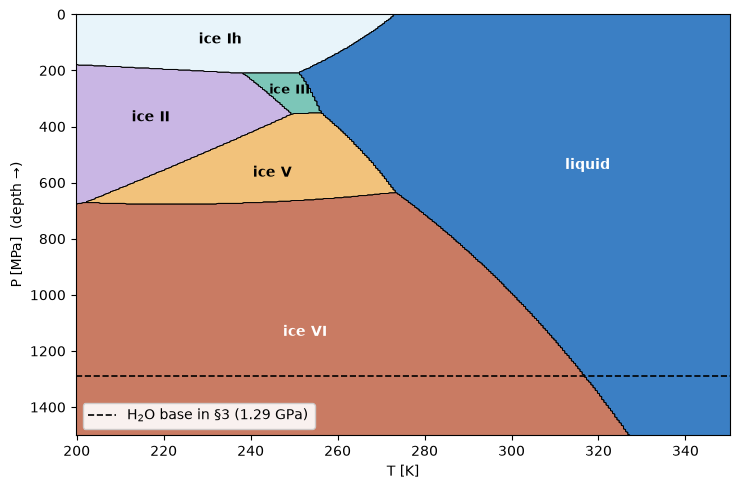

In [5]:
import logging
from matplotlib.colors import ListedColormap
from seafreeze import seafreeze as sf
logging.getLogger("lbftd").disabled = True      # silence harmless spline-range warnings

P_grid = np.linspace(0.1, 1500, 601)    # MPa
T_grid = np.linspace(200, 350, 301)     # K
phase = sf.whichphase(np.array([P_grid, T_grid], dtype=object))   # shape (nP, nT)

codes  = [0, 1, 2, 3, 5, 6]
names  = {0: "liquid", 1: "ice Ih", 2: "ice II", 3: "ice III", 5: "ice V", 6: "ice VI"}
colors = {0: "#3b7fc4", 1: "#e8f4fa", 2: "#c9b6e4", 3: "#7cc6b8", 5: "#f2c27b", 6: "#c97b63"}
idx = np.vectorize({c: i for i, c in enumerate(codes)}.get)(phase)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.pcolormesh(T_grid, P_grid, idx, cmap=ListedColormap([colors[c] for c in codes]),
              shading="nearest", vmin=-0.5, vmax=len(codes) - 0.5)
for c in codes:   # one contour per phase, so boundaries are clean lines
    ax.contour(T_grid, P_grid, (phase == c).astype(float), levels=[0.5], colors="k", linewidths=0.6)
for c in codes:   # label each field at its median position
    jj, ii = np.nonzero(phase == c)
    ax.text(np.median(T_grid[ii]), np.median(P_grid[jj]), names[c], ha="center", va="center",
            fontsize=9 if c == 3 else 10, fontweight="bold", color="white" if c in (0, 6) else "k")

ax.axhline(gan.P[i_h2o] / 1e6, c="k", ls="--", lw=1.2,
           label=f"H$_2$O base in §3 ({gan.P[i_h2o]/1e9:.2f} GPa)")
ax.invert_yaxis()
ax.set_xlabel("T [K]"); ax.set_ylabel("P [MPa]  (depth →)")
ax.legend(loc="lower left", framealpha=0.9)
plt.tight_layout(); plt.show()

## 6. Temperature path through the H2O layer

- **Ice Ih shell:** conductive, with k = 651/T (Petrenko & Whitworth) and constant heat flux q, so dT/dz = qT/a. It ends where the path crosses the Ih melting curve.
- **Ocean and high-pressure ice:** assumed to be well mixed, so they follow an adiabat, dT/dz = αgT/c_p, with α, c_p and ρ from SeaFreeze.
- **Pressure:** dP/dz = ρg, with g from §3.

SeaFreeze is slow when called point by point, so the properties are tabulated once and then interpolated.

q = 5 mW/m^2
  ice Ih     0.0 –  111.2 km   T 110.0 – 258.3 K   P     0 –   150 MPa
  liquid   111.3 –  338.5 km   T 258.5 – 268.3 K   P   150 –   529 MPa
  ice V    338.6 –  395.3 km   T 268.3 – 270.4 K   P   529 –   639 MPa
  ice VI   395.4 –  751.5 km   T 270.4 – 286.6 K   P   639 –  1439 MPa
  layer thicknesses: shell 111 km, ocean 227 km, HP ice 413 km
  mean H2O density: 1218 kg/m^3  (§3 assumed 1100)

q = 15 mW/m^2
  ice Ih     0.0 –   38.7 km   T 110.0 – 268.0 K   P     0 –    52 MPa
  liquid    38.8 –  495.5 km   T 268.7 – 288.9 K   P    52 –   831 MPa
  ice VI   495.6 –  751.5 km   T 288.9 – 301.3 K   P   831 –  1419 MPa
  layer thicknesses: shell 39 km, ocean 457 km, HP ice 256 km
  mean H2O density: 1202 kg/m^3  (§3 assumed 1100)

q = 40 mW/m^2
  ice Ih     0.0 –   14.7 km   T 110.0 – 270.7 K   P     0 –    20 MPa
  liquid    14.8 –  545.1 km   T 272.3 – 296.0 K   P    20 –   931 MPa
  ice VI   545.2 –  751.5 km   T 296.0 – 306.2 K   P   931 –  1411 MPa
  layer thicknesses:

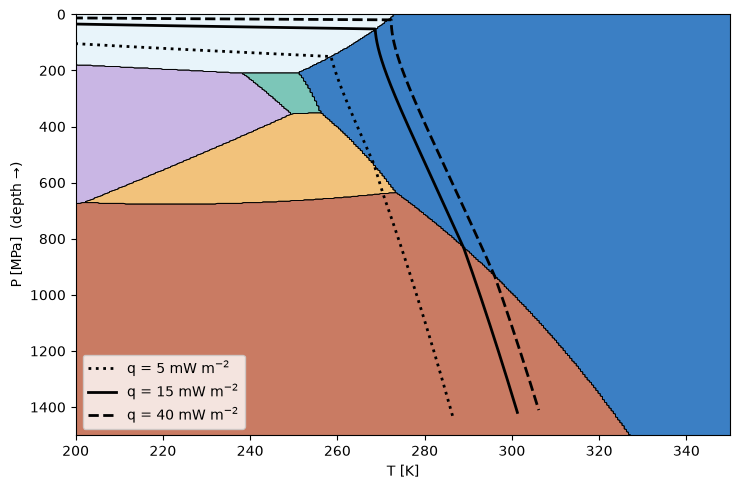

In [6]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

# --- 1. Property tables: evaluate SeaFreeze once per phase, then interpolate ---
P_tab = np.linspace(0.1, 2000, 801)     # MPa (deeper than cell 5, in case P overshoots)
T_tab = np.linspace(100, 350, 251)      # K   (down to the surface temperature)
PT_tab = np.array([P_tab, T_tab], dtype=object)
phase_tab = sf.whichphase(PT_tab)

def fill_nan(a):
    """SeaFreeze returns NaN outside each phase's fitted range. Fill with the nearest valid
    value so interpolation right at a phase boundary doesn't pick up NaN neighbours."""
    nan = np.isnan(a)
    if not nan.any():
        return a
    i = distance_transform_edt(nan, return_distances=False, return_indices=True)
    return a[tuple(i)]

SF_NAME = {0: "water1", 1: "Ih", 3: "III", 5: "V", 6: "VI"}
tables = {}
for code, name in SF_NAME.items():
    out = sf.getProp(PT_tab, name)
    tables[code] = {k: RegularGridInterpolator((P_tab, T_tab), fill_nan(np.asarray(getattr(out, k), float)))
                    for k in ("rho", "alpha", "Cp")}
phase_lookup = RegularGridInterpolator((P_tab, T_tab), phase_tab.astype(float), method="nearest")

# --- 2. March down through the H2O layer ---
def h2o_column(q_surf, T_surf=110.0, a_k=651.0, h2o_thick=R_GANYMEDE - r_mantle, dz=100.0):
    """Ice Ih shell: conductive with k = a/T and constant flux q   ->  dT/dz = q T / a
    Ocean and high-pressure ice: adiabatic                         ->  dT/dz = alpha g T / cp
    Pressure: dP/dz = rho g, with g from the §3 profile and rho from SeaFreeze."""
    z, P, T = 0.0, 0.1, T_surf                      # depth [m], P [MPa], T [K]
    rows, hp_ice = [], None
    while z <= h2o_thick:
        ph = int(phase_lookup((P, T)))
        if ph == 2:                                  # cold-side ice II: treat as Ih at these conditions
            ph = 1
        if hp_ice is None and ph in (3, 5, 6) and rows and rows[-1][3] == 0:
            hp_ice = ph                              # first solid below the ocean
        if hp_ice is not None and ph == 0:
            ph = rows[-1][3]                         # stay solid below the ocean
        prop = {k: float(f((P, T))) for k, f in tables[ph].items()}
        g = np.interp(R_GANYMEDE - z, gan.r, gan.g)
        rows.append((z, P, T, ph, prop["rho"]))
        dTdz = q_surf * T / a_k if ph == 1 else prop["alpha"] * g * T / prop["Cp"]
        T += dTdz * dz
        P += prop["rho"] * g * dz / 1e6
        z += dz
    return np.array(rows)

def summarize(col):
    z, P, T, ph, rho = col.T
    _, first = np.unique(ph, return_index=True)
    for p in ph[np.sort(first)]:
        m = ph == p
        print(f"  {names[int(p)]:7s} {z[m].min()/1e3:6.1f} – {z[m].max()/1e3:6.1f} km   "
              f"T {T[m].min():5.1f} – {T[m].max():5.1f} K   P {P[m].min():5.0f} – {P[m].max():5.0f} MPa")
    print(f"  layer thicknesses: shell {np.ptp(z[ph==1])/1e3:.0f} km, ocean {np.ptp(z[ph==0])/1e3:.0f} km, "
          f"HP ice {np.ptp(z[np.isin(ph,(3,5,6))])/1e3:.0f} km")
    print(f"  mean H2O density: {rho.mean():.0f} kg/m^3  (§3 assumed {rho_h2o:.0f})")

for q in (0.005, 0.015, 0.040):
    print(f"q = {q*1e3:.0f} mW/m^2"); summarize(h2o_column(q)); print()

# --- 3. Overlay on the phase diagram ---
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.pcolormesh(T_grid, P_grid, idx, cmap=ListedColormap([colors[c] for c in codes]),
              shading="nearest", vmin=-0.5, vmax=len(codes) - 0.5)
for c in codes:
    ax.contour(T_grid, P_grid, (phase == c).astype(float), levels=[0.5], colors="k", linewidths=0.6)
for q, ls in [(0.005, ":"), (0.015, "-"), (0.040, "--")]:
    c_ = h2o_column(q)
    ax.plot(c_[:, 2], c_[:, 1], "k", ls=ls, lw=2, label=f"q = {q*1e3:.0f} mW m$^{{-2}}$")
ax.invert_yaxis(); ax.set_xlim(T_grid[0], T_grid[-1])
ax.set_xlabel("T [K]"); ax.set_ylabel("P [MPa]  (depth →)"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 7. Self-consistent structure

The fit in §3 assumed a uniform H2O density of 1100 kg/m^3, but the SeaFreeze column in §6 is about 1200 and stratified.
Iterate: fit the radii (with the *actual* H2O density profile in M and C/MR^2) → recompute the column → repeat until converged.

In [7]:
from scipy.optimize import fsolve

def fit_with_h2o_profile(z_w, rho_w, guess):
    """Like fit_three_layer, but the H2O layer has a depth-dependent density rho_w(z).
    Unknowns: core radius and mantle top radius."""
    R = R_GANYMEDE
    def residuals(x):
        rc, rm = x * R
        r_w = np.linspace(rm, R, 2000)
        rho_r = np.interp(R - r_w, z_w, rho_w)            # H2O density at each radius
        m_w = np.trapezoid(4 * np.pi * r_w**2 * rho_r, r_w)
        I_w = np.trapezoid(8 * np.pi / 3 * r_w**4 * rho_r, r_w)
        m = 4 * np.pi / 3 * (rho_core * rc**3 + rho_mantle * (rm**3 - rc**3)) + m_w
        I = 8 * np.pi / 15 * (rho_core * rc**5 + rho_mantle * (rm**5 - rc**5)) + I_w
        return [m / M_GANYMEDE - 1, I / (M_GANYMEDE * R**2) / MOI_GANYMEDE - 1]
    sol, _, ier, msg = fsolve(residuals, guess, full_output=True)
    if ier != 1:
        raise RuntimeError(msg)
    return sol[0] * R, sol[1] * R

def self_consistent(q_surf, tol_km=0.5, max_iter=20):
    rc, rm = fit_three_layer(R_GANYMEDE, M_GANYMEDE, MOI_GANYMEDE, rho_core, rho_mantle, rho_h2o)
    r = np.linspace(0, R_GANYMEDE, 20001)
    col = None
    for it in range(max_iter):
        rho_full = layered_density(r, [rc, rm, R_GANYMEDE], [rho_core, rho_mantle, rho_h2o])
        if col is not None:                               # swap in the SeaFreeze H2O column
            w = r >= rm
            rho_full[w] = np.interp(R_GANYMEDE - r[w], col[:, 0], col[:, 4])
        prof = hydrostatic_profile(r, rho_full)
        globals()["gan"] = prof                           # h2o_column reads g from `gan`
        col = h2o_column(q_surf, h2o_thick=R_GANYMEDE - rm)
        rc_new, rm_new = fit_with_h2o_profile(col[:, 0], col[:, 4], guess=[rc / R_GANYMEDE, rm / R_GANYMEDE])
        change = abs(rm_new - rm) / 1e3
        print(f"  iter {it}: H2O {(R_GANYMEDE - rm_new)/1e3:6.1f} km, core {rc_new/1e3:5.0f} km, "
              f"mean rho_H2O {col[:, 4].mean():6.1f}, change {change:6.2f} km")
        rc, rm = rc_new, rm_new
        if change < tol_km:
            break
    else:
        print("  WARNING: not converged")
    col = h2o_column(q_surf, h2o_thick=R_GANYMEDE - rm)
    return rc, rm, col, prof

results = {}
for q in (0.005, 0.015, 0.040):
    print(f"q = {q*1e3:.0f} mW/m^2")
    results[q] = self_consistent(q)
    rc_, rm_, col_, prof_ = results[q]
    summarize(col_)
    print(f"  check: M = {prof_.mass:.4e} kg, C/MR^2 = {prof_.moi:.4f}\n")
    

q = 5 mW/m^2
  iter 0: H2O  808.2 km, core   758 km, mean rho_H2O 1218.2, change  56.62 km
  iter 1: H2O  809.4 km, core   761 km, mean rho_H2O 1231.3, change   1.27 km
  iter 2: H2O  809.4 km, core   761 km, mean rho_H2O 1231.5, change   0.00 km
  ice Ih     0.0 –  111.2 km   T 110.0 – 258.3 K   P     0 –   151 MPa
  liquid   111.3 –  335.5 km   T 258.5 – 268.3 K   P   151 –   529 MPa
  ice V    335.6 –  391.9 km   T 268.3 – 270.4 K   P   529 –   639 MPa
  ice VI   392.0 –  809.4 km   T 270.4 – 288.8 K   P   639 –  1569 MPa
  layer thicknesses: shell 111 km, ocean 224 km, HP ice 474 km
  mean H2O density: 1232 kg/m^3  (§3 assumed 1100)
  check: M = 1.4819e+23 kg, C/MR^2 = 0.3115

q = 15 mW/m^2
  iter 0: H2O  801.6 km, core   764 km, mean rho_H2O 1201.6, change  50.07 km
  iter 1: H2O  803.3 km, core   767 km, mean rho_H2O 1215.0, change   1.66 km
  iter 2: H2O  803.3 km, core   767 km, mean rho_H2O 1215.3, change   0.00 km
  ice Ih     0.0 –   38.7 km   T 110.0 – 268.0 K   P     0 –  

In [8]:
from ganymede.thermal import H2OTables, self_consistent_model

tables = H2OTables()                       # ~5 s, build once and reuse
for q in (0.005, 0.015, 0.040):
    m = self_consistent_model(q, tables)
    c = m.column
    print(f"q = {q*1e3:2.0f} mW/m^2 | H2O {(R_GANYMEDE - m.r_mantle)/1e3:5.0f} km | "
          f"shell {c.shell/1e3:5.1f} | ocean {c.ocean/1e3:4.0f} | HP ice {c.hp_ice/1e3:4.0f} km | "
          f"{[names[p] for p in c.sequence()]}")

q =  5 mW/m^2 | H2O   809 km | shell 111.2 | ocean  224 | HP ice  474 km | ['ice Ih', 'liquid', 'ice V', 'ice VI']
q = 15 mW/m^2 | H2O   802 km | shell  38.7 | ocean  455 | HP ice  308 km | ['ice Ih', 'liquid', 'ice VI']
q = 40 mW/m^2 | H2O   799 km | shell  14.7 | ocean  537 | HP ice  247 km | ['ice Ih', 'liquid', 'ice VI']
